In [32]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [33]:
df = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/Fraud_Data.csv')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588912 entries, 0 to 588911
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           588912 non-null  int64  
 1   is_fraud                 588912 non-null  int64  
 2   transaction_time         588912 non-null  int64  
 3   transaction_amount       588912 non-null  float64
 4   card_network             588912 non-null  object 
 5   card_type                588912 non-null  object 
 6   purchaser_email_domain   494686 non-null  object 
 7   device_type              140606 non-null  object 
 8   is_identity_seen_before  129173 non-null  object 
 9   user_os                  144028 non-null  object 
 10  user_browser             144028 non-null  object 
 11  environment              144028 non-null  object 
 12  environment_freq         144028 non-null  float64
 13  environment_risk         144028 non-null  float64
 14  devi

In [35]:
df.columns.tolist()

['transaction_id',
 'is_fraud',
 'transaction_time',
 'transaction_amount',
 'card_network',
 'card_type',
 'purchaser_email_domain',
 'device_type',
 'is_identity_seen_before',
 'user_os',
 'user_browser',
 'environment',
 'environment_freq',
 'environment_risk',
 'device_os_invalid',
 'card_info']

In [36]:
df[['is_fraud',
    'transaction_amount',
    'card_network',
    'card_type',
    'purchaser_email_domain',
    'device_type',
    'is_identity_seen_before',
    'user_os',
    'user_browser',
    'environment_risk',
    'device_os_invalid',
    ]].head(10)

,is_fraud,transaction_amount,card_network,card_type,purchaser_email_domain,device_type,is_identity_seen_before,user_os,user_browser,environment_risk,device_os_invalid
0,0,68.5,discover,credit,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,29.0,mastercard,credit,gmail.com,NaN,NaN,NaN,NaN,NaN,NaN
2,0,59.0,visa,debit,outlook.com,NaN,NaN,NaN,NaN,NaN,NaN
3,0,50.0,mastercard,debit,yahoo.com,NaN,NaN,NaN,NaN,NaN,NaN
4,0,50.0,mastercard,credit,gmail.com,mobile,New,Android,Samsung,1.0,0.0
5,0,49.0,visa,debit,gmail.com,NaN,NaN,NaN,NaN,NaN,NaN
6,0,159.0,visa,debit,yahoo.com,NaN,NaN,NaN,NaN,NaN,NaN
7,0,422.5,visa,debit,mail.com,NaN,NaN,NaN,NaN,NaN,NaN
8,0,15.0,visa,debit,anonymous.com,mobile,New,iOS,Safari,0.0,0.0
9,0,117.0,mastercard,debit,yahoo.com,NaN,NaN,NaN,NaN,NaN,NaN


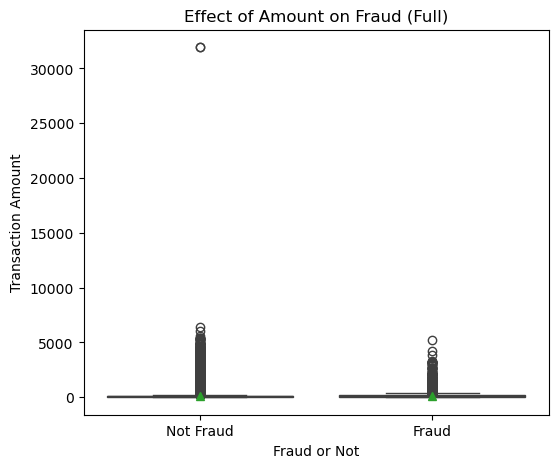

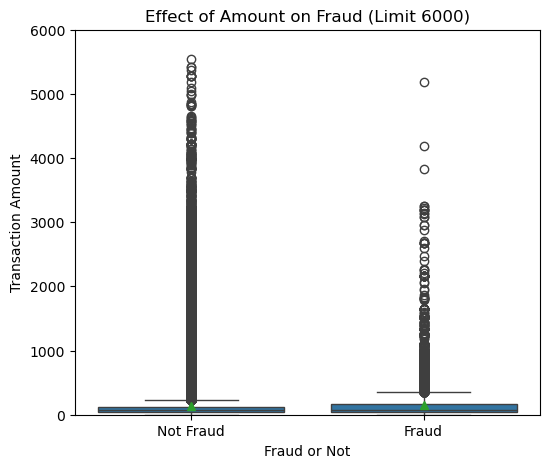

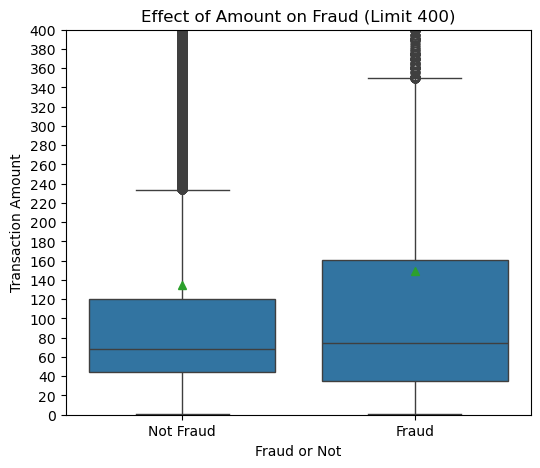

In [37]:
def plot_fraud_box(df, ylim=None, yticks=None, title_suffix="Full"):
    plt.figure(figsize=(6, 5))

    sns.boxplot(
        data=df,
        x='is_fraud',
        y='transaction_amount',
        showmeans=True
    )

    plt.xticks([0, 1], ['Not Fraud', 'Fraud'])
    plt.xlabel('Fraud or Not')
    plt.ylabel('Transaction Amount')
    plt.title(f'Effect of Amount on Fraud ({title_suffix})')

    if ylim:
        plt.ylim(0, ylim)
    if yticks and ylim:
        plt.yticks(range(0, ylim + 1, yticks))

    plt.show()

# Calls stay the same
plot_fraud_box(df)
plot_fraud_box(df, ylim=6000, title_suffix="Limit 6000")
plot_fraud_box(df, ylim=400, yticks=20, title_suffix="Limit 400")

In [38]:
df['log_amt'] = np.log1p(df['transaction_amount'])
df.groupby('is_fraud')['log_amt'].agg(['count', 'mean', 'median', 'std'])

,count,mean,median,std
is_fraud,,,,
0,568290,4.383072,4.241327,0.930366
1,20622,4.373968,4.330733,1.105116


In [39]:
df.groupby('is_fraud')['transaction_amount'].agg(['count', 'mean', 'median', 'std'])

,count,mean,median,std
is_fraud,,,,
0,568290,134.459950,68.5,239.300101
1,20622,149.269889,75.0,232.360011


In [40]:
df['amount_bin'] = pd.qcut(df['transaction_amount'], q=10, duplicates='drop')
bin_summary = df.groupby('amount_bin')['is_fraud'].agg(['count', 'mean'])
bin_summary.rename(columns={'mean': 'fraud_rate'}, inplace=True)
bin_summary['fraud_rate'] = bin_summary['fraud_rate'].round(5)  # 4 decimal places
bin_summary

/tmp/ipykernel_4840/1908708531.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_summary = df.groupby('amount_bin')['is_fraud'].agg(['count', 'mean'])


,count,fraud_rate
amount_bin,,
"(0.25, 25.95]",59366,0.05599
"(25.95, 35.95]",61491,0.03200
"(35.95, 49.0]",64941,0.03226
"(49.0, 57.95]",59496,0.01940
"(57.95, 68.586]",49162,0.02860
"(68.586, 100.0]",73245,0.03619
"(100.0, 117.0]",71815,0.01975
"(117.0, 159.95]",32324,0.04309
"(159.95, 275.0]",58225,0.03796


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, '(0.25, 25.95]'),
  Text(1, 0, '(25.95, 35.95]'),
  Text(2, 0, '(35.95, 49.0]'),
  Text(3, 0, '(49.0, 57.95]'),
  Text(4, 0, '(57.95, 68.586]'),
  Text(5, 0, '(68.586, 100.0]'),
  Text(6, 0, '(100.0, 117.0]'),
  Text(7, 0, '(117.0, 159.95]'),
  Text(8, 0, '(159.95, 275.0]'),
  Text(9, 0, '(275.0, 31937.391]')])

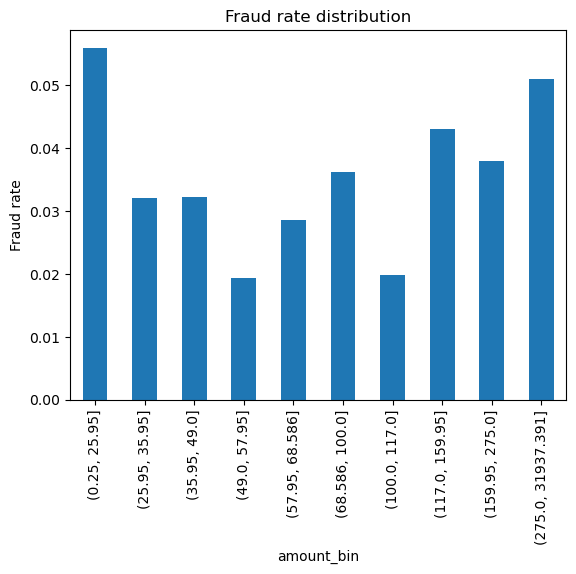

In [41]:
bin_summary['fraud_rate'].plot(kind='bar')
plt.ylabel('Fraud rate')
plt.title('Fraud rate distribution')
plt.xticks(rotation=90)

In [42]:
print(df['card_network'].value_counts())
print(df['is_fraud'].value_counts())

card_network
visa                384755
mastercard          189187
american express      8319
discover              6651
Name: count, dtype: int64
is_fraud
0    568290
1     20622
Name: count, dtype: int64


In [43]:
pd.crosstab(df['card_network'], df['is_fraud'])

is_fraud,0,1
card_network,,
american express,8080,239
discover,6137,514
mastercard,182691,6496
visa,371382,13373


In [44]:
ct = pd.crosstab(df['card_network'], df['is_fraud'], normalize='index')
(ct * 100).round(3)

is_fraud,0,1
card_network,,
american express,97.127,2.873
discover,92.272,7.728
mastercard,96.566,3.434
visa,96.524,3.476


<Axes: xlabel='card_network'>

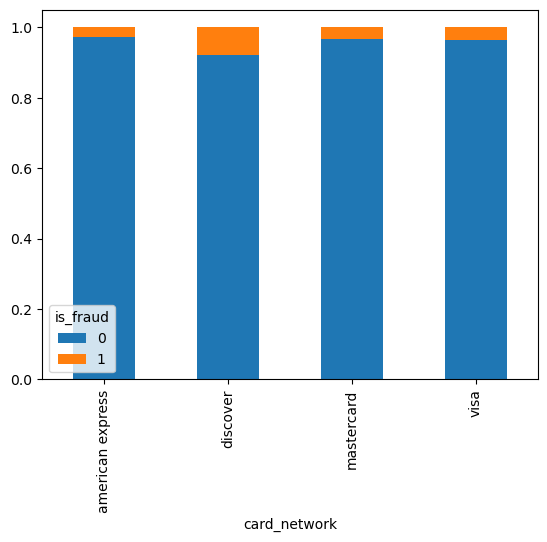

In [45]:
ct.plot(kind='bar', stacked=True)


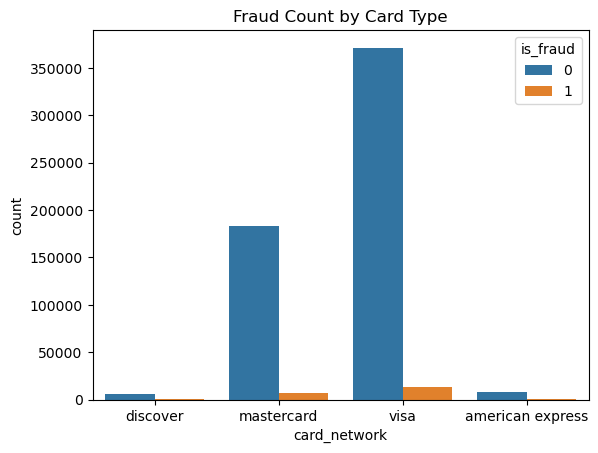

In [46]:
sns.countplot(x='card_network', hue='is_fraud', data=df)
plt.title("Fraud Count by Card Type")
plt.show()

In [47]:
chi2, p, dof, exp = chi2_contingency(ct)
print(p)

0.9981805621345234


In [48]:
if p < 0.05:
    print("card_network is useful")
else:
    print("card_network not useful")

card_network not useful


In [49]:
df['card_type'].value_counts()

card_type
debit     439929
credit    148983
Name: count, dtype: int64

In [50]:
(df['card_type'].value_counts(normalize=True) * 100).round(3)

card_type
debit     74.702
credit    25.298
Name: proportion, dtype: float64

In [51]:
ct = pd.crosstab(df['card_type'] , df['is_fraud'])
ct

is_fraud,0,1
card_type,,
credit,139034,9949
debit,429256,10673


In [52]:
(pd.crosstab(df['card_type'] , df['is_fraud'], normalize='index')* 100).round(3)

is_fraud,0,1
card_type,,
credit,93.322,6.678
debit,97.574,2.426


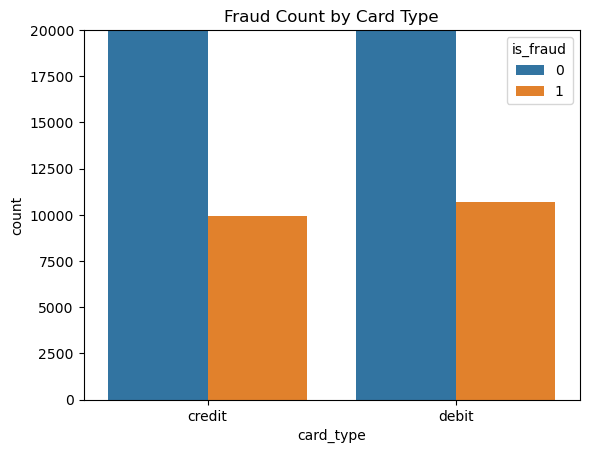

In [53]:
sns.countplot(x='card_type', hue='is_fraud' , data=df)
plt.title("Fraud Count by Card Type")
plt.ylim(0,20000)
plt.show()

In [54]:
chi2, p, dof, exp = chi2_contingency(ct)
print(f"{p:.10e}")

0.0000000000e+00


In [55]:
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(cramers_v)

0.10054102847868875


In [56]:
ct = pd.crosstab(df['card_info'], df['is_fraud'])
ct

is_fraud,0,1
card_info,,
american express_credit,7941,234
american express_debit,139,5
discover_credit,5804,500
discover_debit,333,14
mastercard_credit,47261,3511
mastercard_debit,135430,2985
visa_credit,78028,5704
visa_debit,293354,7669


In [57]:
((pd.crosstab(df['card_info'], df['is_fraud'] , normalize='index')) * 100).round(3)

is_fraud,0,1
card_info,,
american express_credit,97.138,2.862
american express_debit,96.528,3.472
discover_credit,92.069,7.931
discover_debit,95.965,4.035
mastercard_credit,93.085,6.915
mastercard_debit,97.843,2.157
visa_credit,93.188,6.812
visa_debit,97.452,2.548


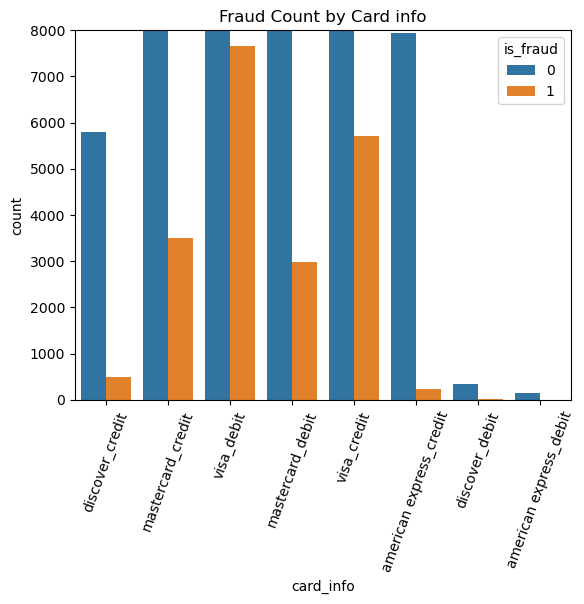

In [58]:
sns.countplot(x='card_info', hue='is_fraud' , data=df)
plt.title("Fraud Count by Card info")
plt.ylim(0,8000)
plt.xticks(rotation=70)
plt.show()

In [59]:
chi2 , p, dof, exp = chi2_contingency(ct)
print(f"{p:.10e}")

0.0000000000e+00


In [60]:
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(cramers_v)

0.10420470431251345


In [68]:
(df['purchaser_email_domain'].value_counts(normalize=True).mul(100).sort_values(ascending=False)).round(4)

purchaser_email_domain
gmail.com           46.0252
yahoo.com           20.3470
hotmail.com          9.1238
anonymous.com        7.4619
aol.com              5.7032
comcast.net          1.5907
icloud.com           1.2634
outlook.com          1.0273
msn.com              0.8252
att.net              0.8114
live.com             0.6135
sbcglobal.net        0.5988
verizon.net          0.5452
ymail.com            0.4825
bellsouth.net        0.3845
yahoo.com.mx         0.3113
me.com               0.3073
cox.net              0.2806
optonline.net        0.2038
charter.net          0.1643
live.com.mx          0.1504
rocketmail.com       0.1342
mail.com             0.1130
earthlink.net        0.1039
gmail                0.0999
outlook.es           0.0885
mac.com              0.0881
juno.com             0.0647
aim.com              0.0635
hotmail.es           0.0617
roadrunner.com       0.0615
windstream.net       0.0615
hotmail.fr           0.0596
frontier.com         0.0566
embarqmail.com       0.05

In [76]:
df['purchaser_email_domain'].fillna('NA', inplace=True)
for i in df['purchaser_email_domain'].unique():
    print(i)

NA
gmail.com
outlook.com
yahoo.com
mail.com
anonymous.com
hotmail.com
verizon.net
aol.com
me.com
comcast.net
optonline.net
cox.net
charter.net
rocketmail.com
prodigy.net.mx
embarqmail.com
icloud.com
live.com.mx
gmail
live.com
att.net
juno.com
ymail.com
sbcglobal.net
bellsouth.net
msn.com
q.com
yahoo.com.mx
centurylink.net
servicios-ta.com
earthlink.net
hotmail.es
cfl.rr.com
roadrunner.com
netzero.net
gmx.de
suddenlink.net
frontiernet.net
windstream.net
frontier.com
outlook.es
mac.com
netzero.com
aim.com
web.de
twc.com
cableone.net
yahoo.fr
yahoo.de
yahoo.es
sc.rr.com
ptd.net
live.fr
yahoo.co.uk
hotmail.fr
hotmail.de
hotmail.co.uk
protonmail.com
yahoo.co.jp


In [77]:
def p_email(email):
    email_list = ['NA','gmail.com','yahoo.com','anonymous.com', 'hotmail.com', 'aol.com']
    if email not in email_list:
        return 'others'
    return email

df['purchaser_email_domain'] = df['purchaser_email_domain'].apply(p_email)

In [84]:
(df['purchaser_email_domain']
 .value_counts(normalize=True)
 .sort_values(ascending=False) * 100
).round(3)

purchaser_email_domain
gmail.com        38.661
yahoo.com        17.092
                 16.000
others            9.525
hotmail.com       7.664
anonymous.com     6.268
aol.com           4.791
Name: proportion, dtype: float64

In [83]:
df['purchaser_email_domain'].replace('NA', '', inplace=True)

In [87]:
(pd.crosstab(df['purchaser_email_domain'], df['is_fraud'], normalize='index') * 100).round(3)

is_fraud,0,1
purchaser_email_domain,,
,97.040,2.960
anonymous.com,97.673,2.327
aol.com,97.817,2.183
gmail.com,95.640,4.360
hotmail.com,94.711,5.289
others,96.880,3.120
yahoo.com,97.721,2.279
